# Importancia de variables y relaciones modeladas — figuras

**Tesis MSc — Oscar I. Sánchez P. | Capítulo 5, Sección 5.4.3**

Produce las figuras de la subsección *Variable importance and modelled relationships*:

| # | Figura | Fuente |
|---|---|---|
| 1 | Importancia por permutación: 3 paneles (uno por set), variables agrupadas por modelo | `set_X_mc_importance.csv` (ya existen) |
| 2 | SHAP del random forest: beeswarm global + dependencia para STR y LTR | modelo reajustado |
| 3 | Efectos parciales del GAM: curvas con banda de confianza + niveles categóricos | modelo reajustado |
| 4 | Odds ratios de la regresión logística (forest plot) | modelo reajustado |
| 5 | Superficie STR × LTR de los tres modelos (set C) | modelos reajustados |

## La corrida representativa

Los efectos parciales y SHAP no se guardaron durante el Monte Carlo (habría sido un archivo por corrida). En su lugar se **reconstruye la corrida cuyo AUROC del GAM queda más cerca de la mediana** de las 100 —la "corrida estrella"— usando la misma semilla, así el dataset es idéntico al de esa corrida. Es la misma estrategia de Steger et al. (2024): las métricas se reportan sobre las 100 corridas, las relaciones modeladas se ilustran con una corrida típica.

**Requisito**: este notebook debe correr en la misma carpeta que `mc_common.py`, `mc_set_a.py`, `mc_set_b.py` y `mc_set_c.py`, porque los importa para reconstruir los datasets. Importar cada script ejecuta su preparación (carga de slope units y series), así que la primera celda de la §3 tarda varios minutos.

```bash
pip install shap   # si no está instalado
```

## 1. Librerías y configuración

In [11]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

OUT_DIR = '/home/oisanchezp/Thesis/src/05_Chapter/Montecarlo/'
FIG_DIR = '00Figuras/05Seccion'
os.makedirs(FIG_DIR, exist_ok=True)

SETS   = ['A', 'B', 'C']
MODELS = ['LR', 'GAM', 'RF']
MODEL_COLOR = {'LR': '#4c78a8', 'GAM': '#59a14f', 'RF': '#e15759'}
MODEL_LABEL = {'LR': 'Logistic regression',
               'GAM': 'Generalized additive model',
               'RF': 'Random forest'}

# nombres de las columnas de los CSV de importancia -> etiqueta en la figura
FEAT_LABEL = {
    'T': 'STR\n(1-day rainfall)',
    'P': 'LTR\n(30-day rainfall)',
    'ENSO': 'ENSO phase',
    'slope_mean': 'Slope angle',
    'curva_mean': 'Curvature',
    'cobertura': 'Land cover',
    'suelos': 'Soil type',
}
FEAT_ORDER = ['T', 'P', 'ENSO', 'slope_mean', 'curva_mean',
              'cobertura', 'suelos']

CAT_EN = {
    # land cover
    'Tejido urbano continuo':        'Continuous urban fabric',
    'Tejido urbano discontinuo':     'Discontinuous urban fabric',
    'Territorios agrícolas':         'Agricultural areas',
    'Territorios agricolas':         'Agricultural areas',
    'Tierras agrícolas':             'Agricultural areas',
    'Tierras agricolas':             'Agricultural areas',
    'Bosques':                       'Forests',
    'Tierras desnudas y degradadas': 'Bare and degraded land',
    # soil type
    'Limo-arcilloso':                  'Silty clay',
    'Areno-arcilloso':                 'Sandy clay',
    'Areno-limoso':                    'Sandy silt',
    'Bloques, gravas, arenas y lodos': 'Blocks, gravel, sand and mud',
    # ENSO: los nombres propios se mantienen; 'Neutro' sí se traduce
    'El Niño': 'El Niño', 'La Niña': 'La Niña', 'Neutro': 'Neutral',
    # códigos numéricos, por si cobertura viene como 0-4
    '0': 'Continuous urban fabric', '1': 'Discontinuous urban fabric',
    '2': 'Agricultural areas', '3': 'Forests', '4': 'Bare and degraded land',
}

def to_en(v):
    return CAT_EN.get(str(v).strip(), str(v))

## 2. Figura 1 — importancia por permutación

Un panel por set. Dentro de cada panel, cajas horizontales de la caída de AUROC sobre las 100 corridas, agrupadas por variable y coloreadas por modelo. Horizontal para que los nombres de las variables se lean sin girar la cabeza.

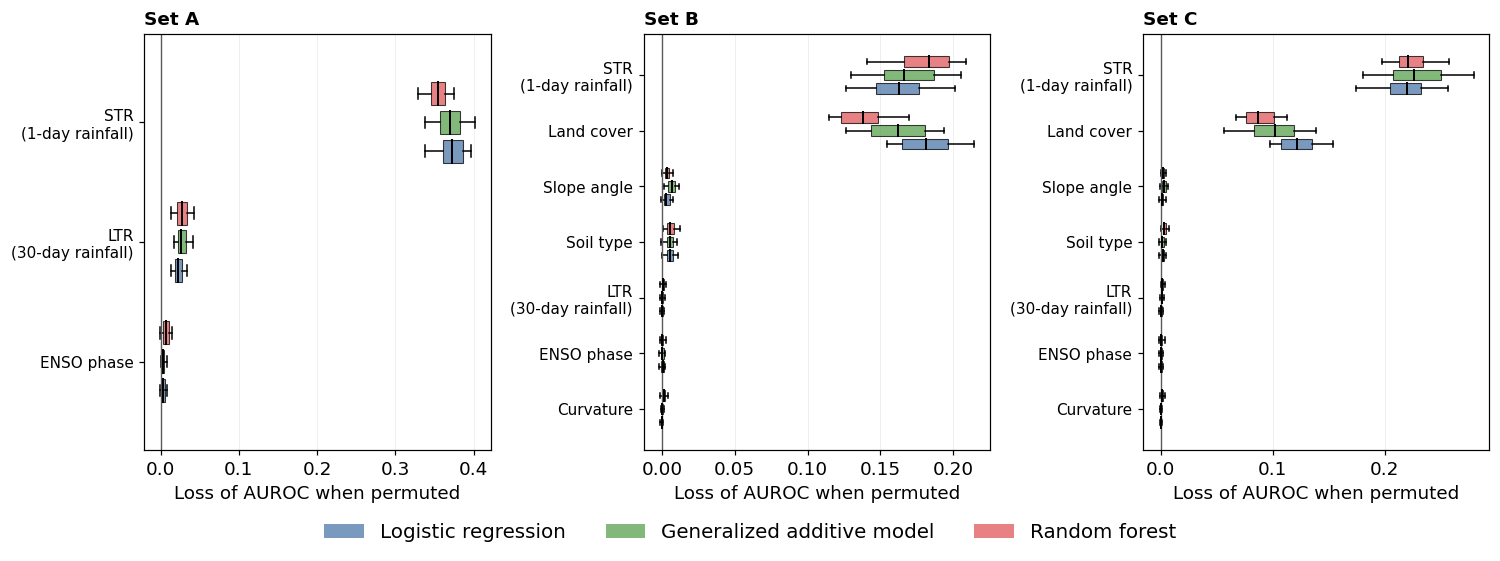


=== Set A: mediana de I_j por modelo ===
            T       P    ENSO
model                        
GAM    0.3701  0.0265  0.0027
LR     0.3723  0.0221  0.0034
RF     0.3544  0.0279  0.0063

=== Set B: mediana de I_j por modelo ===
            T       P    ENSO  slope_mean  curva_mean  cobertura  suelos
model                                                                   
GAM    0.1659  0.0003  0.0002      0.0070      0.0001     0.1623  0.0055
LR     0.1629  0.0000  0.0006      0.0030     -0.0001     0.1815  0.0055
RF     0.1832  0.0009  0.0002      0.0032      0.0012     0.1380  0.0058

=== Set C: mediana de I_j por modelo ===
            T       P    ENSO  slope_mean  curva_mean  cobertura  suelos
model                                                                   
GAM    0.2261  0.0008  0.0004      0.0027      0.0001     0.1022  0.0014
LR     0.2197  0.0002  0.0005      0.0012      0.0000     0.1215  0.0017
RF     0.2212  0.0012  0.0004      0.0016      0.0013     0.0871  0

In [12]:
imp = {}
for s in SETS:
    p = os.path.join(OUT_DIR, f'set_{s}_mc_importance.csv')
    if os.path.exists(p):
        imp[s] = pd.read_csv(p)
    else:
        print(f'AVISO: falta {p}')

SETS_OK = list(imp.keys())

fig, axes = plt.subplots(1, len(SETS_OK), figsize=(4.6 * len(SETS_OK), 5.2),
                         squeeze=False, sharex=False)
W = 0.24

for c, s in enumerate(SETS_OK):
    ax = axes[0][c]
    d = imp[s]
    feats = [f for f in FEAT_ORDER if f in d.columns]
    # variables ordenadas por importancia mediana del GAM (o del primero)
    ref = d[d.model == 'GAM'] if (d.model == 'GAM').any() else d
    orden = (ref[feats].median().sort_values().index.tolist())

    for i, f in enumerate(orden):
        for j, m in enumerate(MODELS):
            vals = d.loc[d.model == m, f].dropna()
            if vals.empty:
                continue
            bp = ax.boxplot(vals.to_numpy(), positions=[i + (j - 1) * W],
                            vert=False, widths=W * 0.8, patch_artist=True,
                            whis=(5, 95), showfliers=False,
                            medianprops=dict(color='black', lw=1.3))
            bp['boxes'][0].set(facecolor=MODEL_COLOR[m], alpha=.75, lw=.7)

    ax.axvline(0, color='0.35', lw=.9)
    ax.set_yticks(range(len(orden)))
    ax.set_yticklabels([FEAT_LABEL.get(f, f) for f in orden], fontsize=10)
    ax.set_title(f'Set {s}', loc='left')
    ax.set_xlabel('Loss of AUROC when permuted')
    ax.grid(axis='x', alpha=.25, lw=.5)
    ax.set_axisbelow(True)

handles = [Patch(facecolor=MODEL_COLOR[m], alpha=.75, label=MODEL_LABEL[m])
           for m in MODELS]
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.005),
           ncol=3, fontsize=13, frameon=False)
fig.savefig(os.path.join(FIG_DIR, 'fig_importance.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

# cifras para el texto
for s in SETS_OK:
    d = imp[s]
    feats = [f for f in FEAT_ORDER if f in d.columns]
    print(f'\n=== Set {s}: mediana de I_j por modelo ===')
    print(d.groupby('model')[feats].median().round(4).to_string())

## 3. Reconstrucción de la corrida representativa

Se identifica, por set, la corrida cuyo AUROC del GAM está más cerca de la mediana, y se reconstruye su dataset con la misma semilla. **Esta celda tarda**: importa los tres scripts y cada import carga slope units y series de pluviómetros.

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from mc_common import CFG, make_models, GamWrapper, _proba1

# run estrella por set (AUROC del GAM mas cercano a su mediana)
run_star = {}
for s in SETS_OK:
    met = pd.read_csv(os.path.join(OUT_DIR, f'set_{s}_mc_metrics.csv'))
    g = met[met.model == 'GAM']
    med = g['auc'].median()
    run_star[s] = int(g.loc[(g['auc'] - med).abs().idxmin(), 'run_id'])
print('Corrida estrella por set:', run_star)

# builders: importar cada script ejecuta su preparacion
builders = {}
import mc_set_a; builders['A'] = (mc_set_a.build_dataset, ['T', 'P'], ['ENSO'])
import mc_set_b; builders['B'] = (mc_set_b.build_dataset,
                                  ['T', 'P', 'slope_mean', 'curva_mean'],
                                  ['cobertura', 'suelos', 'ENSO'])
import mc_set_c; builders['C'] = (mc_set_c.build_dataset,
                                  ['T', 'P', 'slope_mean', 'curva_mean'],
                                  ['cobertura', 'suelos', 'ENSO'])
print('Builders listos.')

2026-08-29 12:37:06,162 | INFO    | ======================================================================
2026-08-29 12:37:06,165 | INFO    | INICIO set_A: 2026-08-29T12:37:06


Corrida estrella por set: {'A': 11, 'B': 26, 'C': 62}


2026-08-29 12:37:40,611 | INFO    | Slope units: 61167 | filas evento: 492
2026-08-29 12:37:40,829 | INFO    |   Est.    1: 2010-01-12 -> 2026-03-18 |  94.0% con dato | 1985 duplicados
2026-08-29 12:37:40,961 | INFO    |   Est.    2: 2010-01-01 -> 2026-03-18 |  90.7% con dato | 249 duplicados
2026-08-29 12:37:41,128 | INFO    |   Est.    3: 2010-01-01 -> 2026-03-18 |  89.5% con dato | 1991 duplicados
2026-08-29 12:37:41,288 | INFO    |   Est.    4: 2010-01-01 -> 2026-03-18 |  84.2% con dato | 1972 duplicados
2026-08-29 12:37:41,431 | INFO    |   Est.    5: 2010-01-01 -> 2026-03-18 |  95.7% con dato | 1991 duplicados
2026-08-29 12:37:41,612 | INFO    |   Est.    7: 2010-01-01 -> 2026-03-18 |  90.6% con dato | 1991 duplicados
2026-08-29 12:37:41,846 | INFO    |   Est.    8: 2010-01-01 -> 2026-03-18 |  89.8% con dato | 1980 duplicados
2026-08-29 12:37:42,000 | INFO    |   Est.    9: 2010-01-01 -> 2026-03-18 |  90.4% con dato | 1990 duplicados
2026-08-29 12:37:42,145 | INFO    |   Est.   1

Builders listos.


In [4]:
# Ajuste de los tres modelos sobre la corrida estrella de cada set,
# con el MISMO split agrupado por slope unit que uso run_montecarlo.
fitted = {}   # set -> dict(models=modelos, Xtr, Xte, ytr, yte, num, cat)

for s in SETS_OK:
    build, num_cols, cat_cols = builders[s]
    seed = CFG['BASE_SEED'] + run_star[s]
    df = build(seed)
    feat = num_cols + cat_cols
    df = df.dropna(subset=['si_no'] + feat).copy()
    y = df['si_no'].astype(int).to_numpy()
    Xdf = df[feat].copy()
    for c in cat_cols:
        Xdf[c] = Xdf[c].astype(str)

    if 'su_uid' in df.columns:
        gss = GroupShuffleSplit(n_splits=1, test_size=CFG['TEST_SIZE'],
                                random_state=seed)
        itr, ite = next(gss.split(Xdf, y, groups=df['su_uid'].to_numpy()))
    else:
        from sklearn.model_selection import train_test_split
        itr, ite = train_test_split(np.arange(len(y)),
                                    test_size=CFG['TEST_SIZE'],
                                    stratify=y, random_state=seed)

    models = make_models(num_cols, cat_cols, seed)
    for name, mdl in models.items():
        if isinstance(mdl, GamWrapper):
            mdl.fit(Xdf.iloc[itr], y[itr], seed=seed)
        else:
            mdl.fit(Xdf.iloc[itr], y[itr])

    fitted[s] = dict(models=models, Xdf=Xdf, y=y, itr=itr, ite=ite,
                     num=num_cols, cat=cat_cols)
    print(f'Set {s}: n={len(y)} | train={len(itr)} | test={len(ite)} | listo')

2026-08-29 12:43:20,050 | WARNING |   47 observaciones sin fase ENSO (fecha fuera de la tabla ONI); se descartan en run_montecarlo


Set A: n=1123 | train=898 | test=225 | listo


2026-08-29 12:43:29,872 | INFO    |   dataset: SI=390 | NO=780 | total=1170


Set B: n=1168 | train=933 | test=235 | listo


2026-08-29 12:43:33,391 | INFO    |   anos presencias: {2016: 2, 2017: 2, 2019: 1, 2020: 1, 2021: 71, 2022: 168, 2023: 66, 2024: 55, 2025: 24}
2026-08-29 12:43:33,393 | INFO    |   anos ausencias : {2016: 3, 2017: 3, 2019: 4, 2021: 132, 2022: 334, 2023: 157, 2024: 102, 2025: 45}
2026-08-29 12:43:33,397 | INFO    |   meses presencias: {1: 11, 3: 21, 4: 37, 5: 80, 6: 73, 7: 2, 8: 23, 9: 34, 10: 41, 11: 61, 12: 7}
2026-08-29 12:43:33,398 | INFO    |   meses ausencias : {1: 24, 3: 34, 4: 70, 5: 168, 6: 132, 7: 1, 8: 52, 9: 74, 10: 80, 11: 131, 12: 14}
2026-08-29 12:43:33,399 | INFO    |   dataset: SI=390 | NO=780 | total=1170


Set C: n=1170 | train=936 | test=234 | listo


## 4. Figura 2 — SHAP del random forest

Beeswarm global (una fila por variable, cada punto una observación del test, color = valor de la variable) y dependencia para STR y LTR. Se hace sobre el set C, que es el modelo completo; cambia `S_SHAP` para otro.

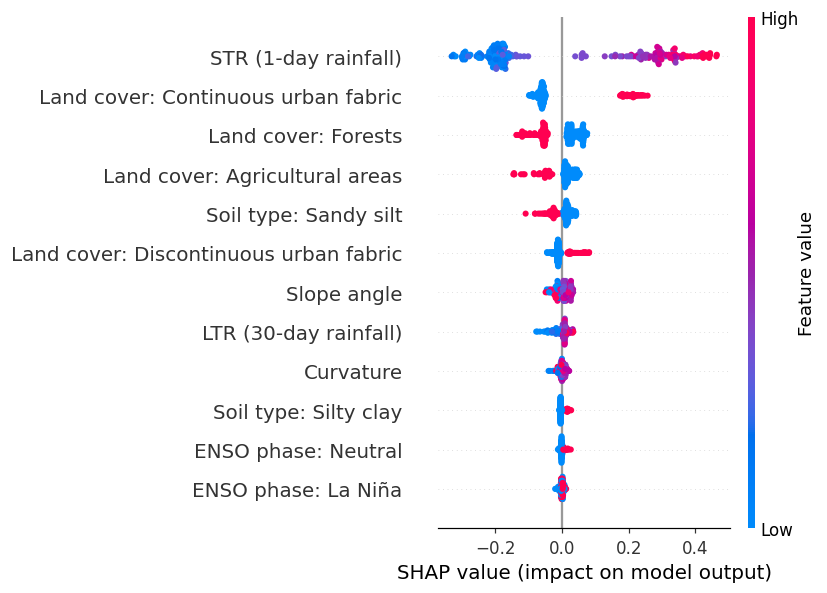

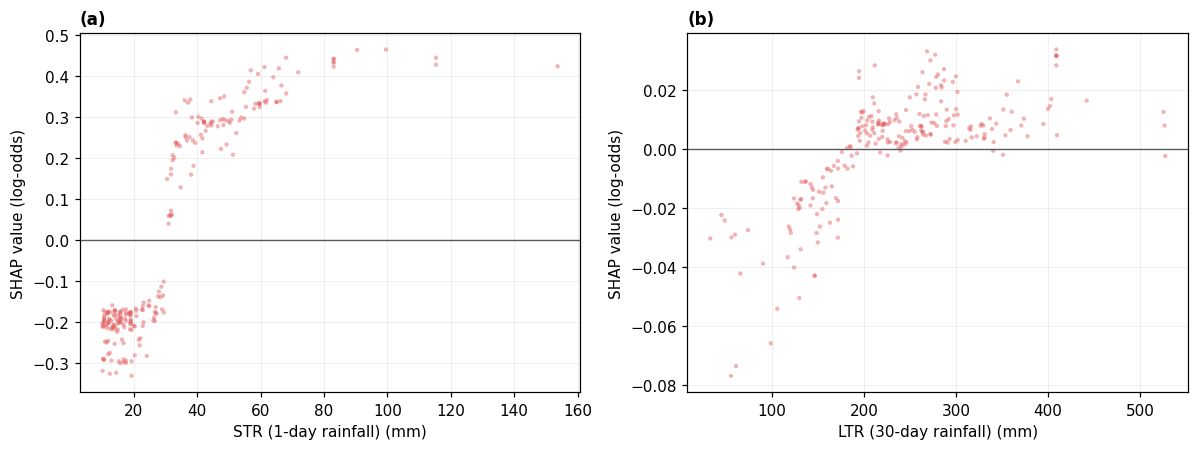

In [12]:
import shap

S_SHAP = 'C'
fs = fitted[S_SHAP]
pipe = fs['models']['RF']
pre, rf = pipe.named_steps['pre'], pipe.named_steps['clf']

Xte = fs['Xdf'].iloc[fs['ite']]
Xt = pre.transform(Xte)
if hasattr(Xt, 'toarray'):
    Xt = Xt.toarray()
names = list(pre.get_feature_names_out())
# limpiar nombres ('num__T' -> 'STR ...', 'cat__cobertura_Bosques' -> ...)
def clean(n):
    n = n.replace('num__', '').replace('cat__', '')
    for k, v in FEAT_LABEL.items():
        if n == k:
            return v
        if n.startswith(k + '_'):
            return f"{FEAT_LABEL[k].split(' (')[0]}: {to_en(n[len(k)+1:])}"
    return n
names = [clean(n) for n in names]

expl = shap.TreeExplainer(rf)
sv = expl.shap_values(Xt)
sv1 = sv[1] if isinstance(sv, list) else (sv[..., 1] if sv.ndim == 3 else sv)

fig = plt.figure(figsize=(7.5, 5.5))
shap.summary_plot(sv1, Xt, feature_names=names, show=False,
                  max_display=12, plot_size=None)
plt.gcf().savefig(os.path.join(FIG_DIR, f'fig_shap_summary_{S_SHAP}.pdf'))
plt.gcf().savefig(os.path.join(FIG_DIR, f'fig_shap_summary_{S_SHAP}.png'))
plt.show()

# dependencia para STR y LTR, una figura de dos paneles
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, var in zip(axes, ['T', 'P']):
    j = names.index(FEAT_LABEL[var])
    ax.scatter(Xt[:, j], sv1[:, j], s=8, alpha=.45, c='#e15759',
               edgecolors='none')
    ax.axhline(0, color='0.35', lw=.9)
    ax.set_xlabel(FEAT_LABEL[var] + ' (mm)')
    ax.set_ylabel('SHAP value (log-odds)')
    ax.grid(alpha=.25, lw=.5)
    ax.set_axisbelow(True)
axes[0].set_title('(a)', loc='left')
axes[1].set_title('(b)', loc='left')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f'fig_shap_dependence_{S_SHAP}.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, f'fig_shap_dependence_{S_SHAP}.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. Figura 3 — efectos parciales del GAM

Las funciones suaves ajustadas con su banda del 95 %, sobre el rango observado, y los niveles de las categóricas como puntos con barra. Todo en escala logit y centrado. Se hace para el set C; el bucle deja las de A y B guardadas también.

--- efectos parciales GAM, set A ---


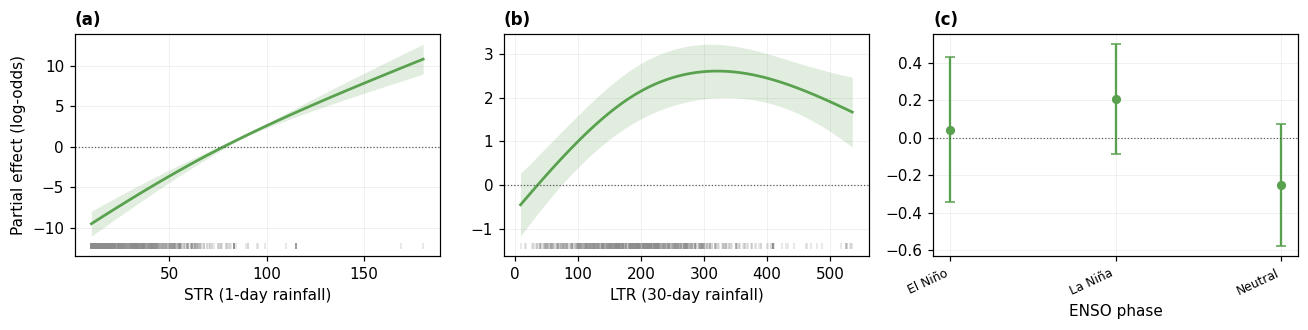

--- efectos parciales GAM, set B ---


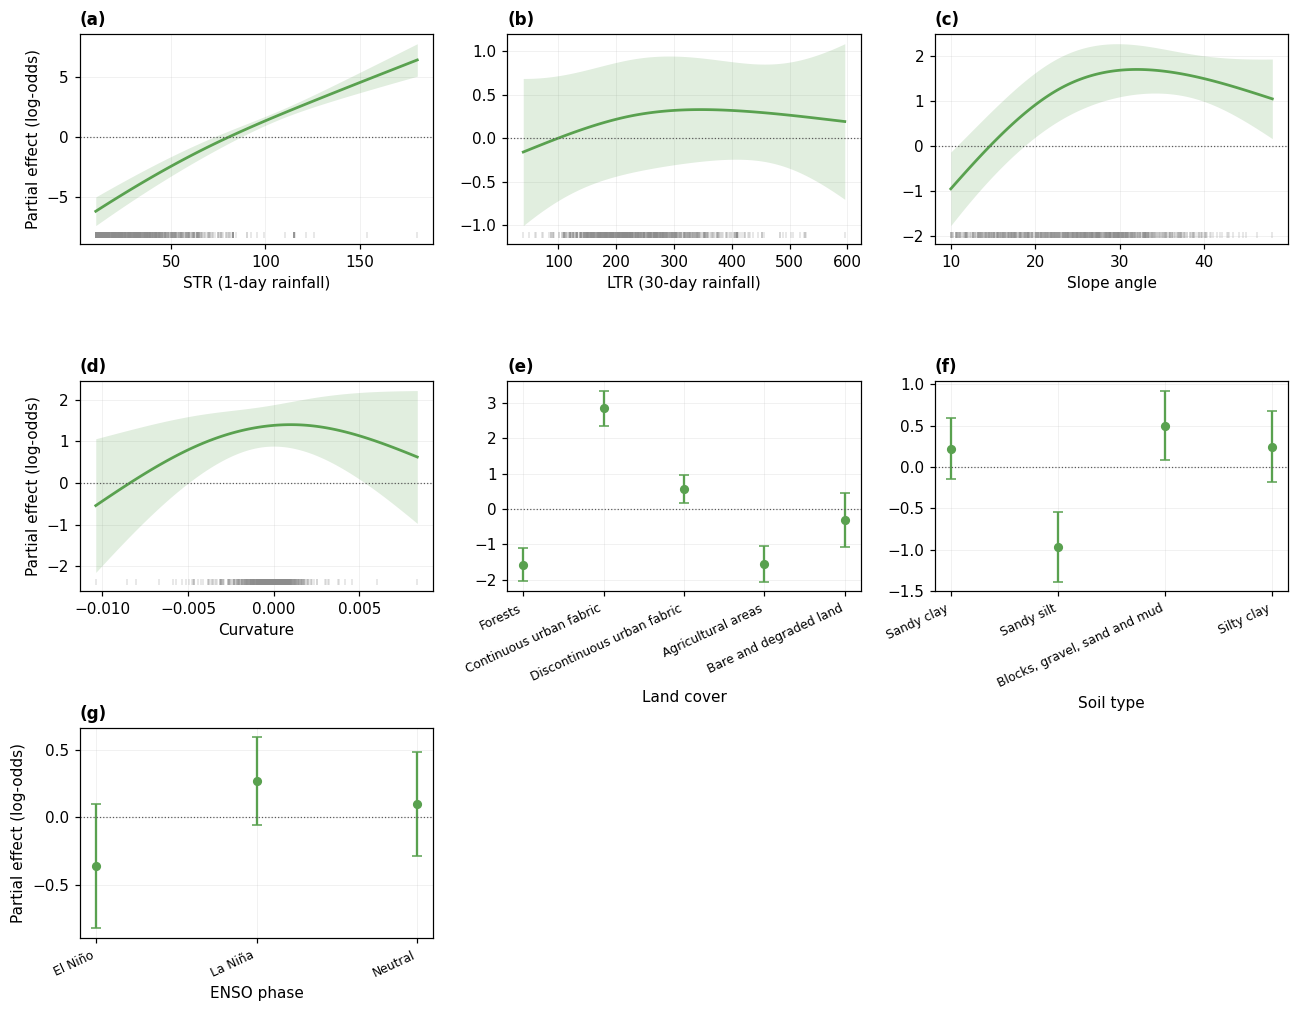

--- efectos parciales GAM, set C ---


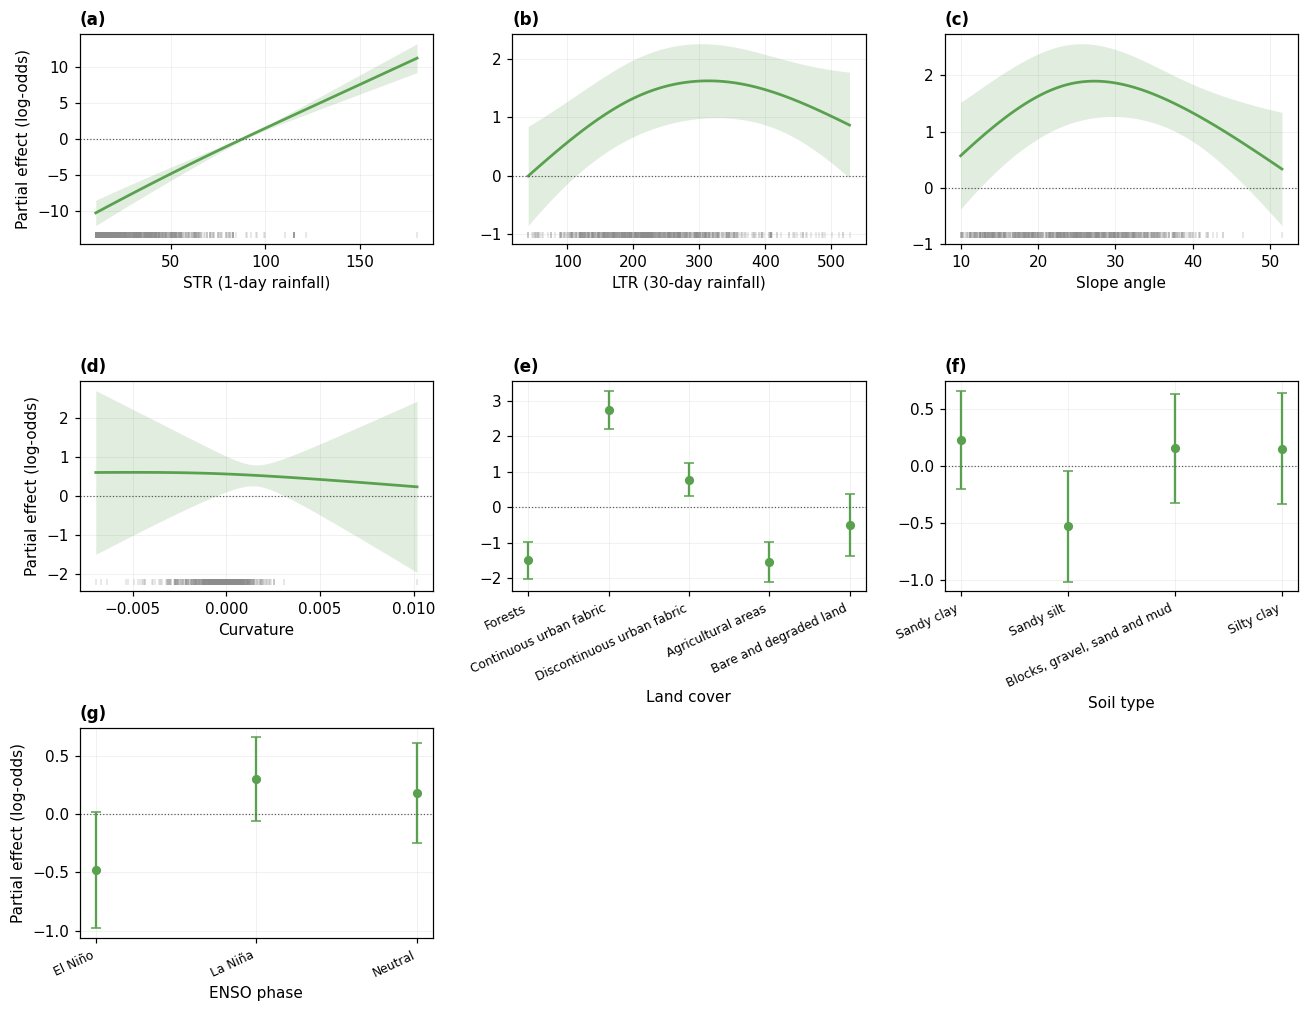

In [14]:
def plot_gam_effects(s):
    fs = fitted[s]
    gw = fs['models']['GAM']          # GamWrapper
    gam = gw.gam
    num, cat = fs['num'], fs['cat']
    cols = num + cat
    Xtr = fs['Xdf'].iloc[fs['itr']]
    Xmat = gw._to_X(Xtr)

    n_pan = len(cols)
    ncol = 3
    nrow = int(np.ceil(n_pan / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.0 * ncol, 3.1 * nrow),
                             squeeze=False)
    letras = 'abcdefghij'

    for j, col in enumerate(cols):
        ax = axes[j // ncol][j % ncol]
        XX = gam.generate_X_grid(term=j)
        pd_, ci = gam.partial_dependence(term=j, X=XX, width=0.95)

        if col in num:
            ax.plot(XX[:, j], pd_, color='#59a14f', lw=1.8)
            ax.fill_between(XX[:, j], ci[:, 0], ci[:, 1],
                            color='#59a14f', alpha=.18, lw=0)
            # alfombra con los valores observados
            ax.plot(Xmat[:, j], np.full(len(Xmat), ax.get_ylim()[0]),
                    '|', color='0.55', ms=4, alpha=.25)
            ax.set_xlabel(FEAT_LABEL.get(col, col))
        else:
            # factor: un punto por nivel con su intervalo
            niveles = [v for v in sorted(fs['Xdf'][col].astype(str).unique())
                       if v.lower() not in ('nan', '<na>', 'none')]
            codes = [gw.cat_maps[col][v] for v in niveles]
            xs, lo_, hi_ = [], [], []
            for cde in codes:
                i = int(np.argmin(np.abs(XX[:, j] - cde)))
                xs.append(pd_[i]); lo_.append(ci[i, 0]); hi_.append(ci[i, 1])
            pos = np.arange(len(niveles))
            ax.errorbar(pos, xs,
                        yerr=[np.array(xs) - np.array(lo_),
                              np.array(hi_) - np.array(xs)],
                        fmt='o', color='#59a14f', capsize=3, ms=5)
            ax.set_xticks(pos)
            ax.set_xticklabels([to_en(v) for v in niveles],
                               rotation=25, ha='right', fontsize=8)
            ax.set_xlabel(FEAT_LABEL.get(col, col))

        ax.axhline(0, color='0.35', lw=.8, ls=':')
        ax.set_title(f'({letras[j]})', loc='left')
        if j % ncol == 0:
            ax.set_ylabel('Partial effect (log-odds)')
        ax.grid(alpha=.22, lw=.5)
        ax.set_axisbelow(True)

    for j in range(n_pan, nrow * ncol):
        axes[j // ncol][j % ncol].set_visible(False)

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f'fig_gam_effects_{s}.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(FIG_DIR, f'fig_gam_effects_{s}.png'), dpi=300, bbox_inches='tight')
    plt.show()

for s in SETS_OK:
    print(f'--- efectos parciales GAM, set {s} ---')
    plot_gam_effects(s)

## 6. Figura 4 — odds ratios de la regresión logística

Forest plot: $e^{\beta_j}$ por desviación estándar para las continuas y por nivel (frente a la referencia) para las categóricas. El intervalo se aproxima con la variabilidad de los coeficientes entre las 100 corridas si guardaste los modelos; si no, se dibuja el valor puntual de la corrida estrella.

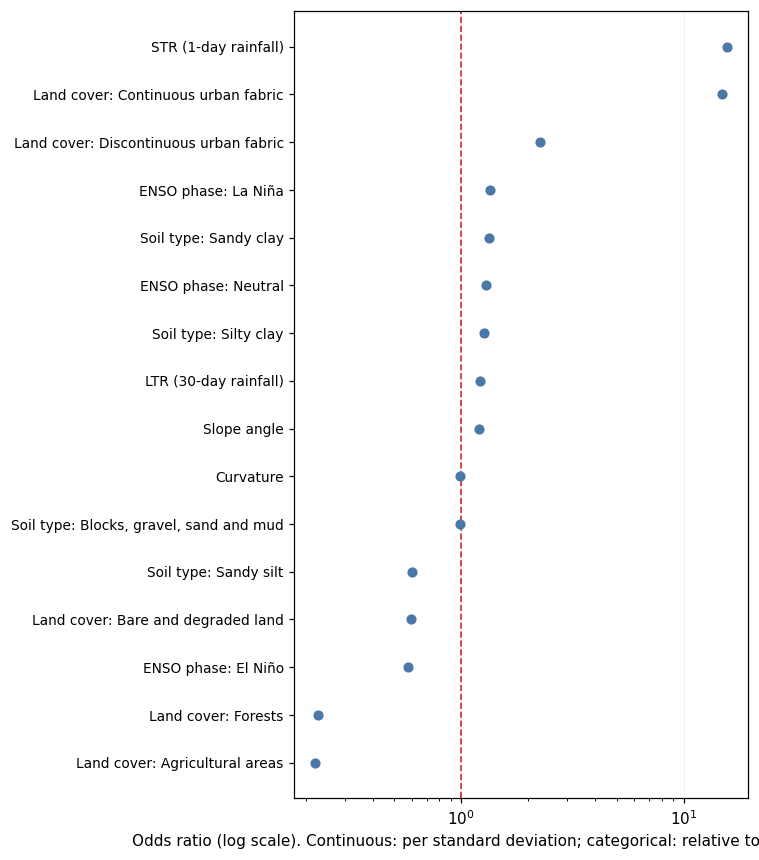

STR (1-day rainfall)                       15.738
Land cover: Continuous urban fabric        14.917
Land cover: Discontinuous urban fabric      2.255
ENSO phase: La Niña                         1.343
Soil type: Sandy clay                       1.336
ENSO phase: Neutral                         1.290
Soil type: Silty clay                       1.266
LTR (30-day rainfall)                       1.221
Slope angle                                 1.203
Curvature                                   0.991
Soil type: Blocks, gravel, sand and mud     0.985
Soil type: Sandy silt                       0.600
Land cover: Bare and degraded land          0.593
ENSO phase: El Niño                         0.577
Land cover: Forests                         0.227
Land cover: Agricultural areas              0.221


In [15]:
S_LR = 'C'
fs = fitted[S_LR]
pipe = fs['models']['LR']
pre, lr = pipe.named_steps['pre'], pipe.named_steps['clf']
names = [clean(n) for n in pre.get_feature_names_out()]
orx = np.exp(lr.coef_.ravel())

orden = np.argsort(orx)
fig, ax = plt.subplots(figsize=(7.0, 0.42 * len(orx) + 1.2))
ax.scatter(orx[orden], np.arange(len(orx)), color='#4c78a8', s=32, zorder=3)
ax.axvline(1, color='#d62728', lw=1.1, ls='--')
ax.set_yticks(np.arange(len(orx)))
ax.set_yticklabels([names[i] for i in orden], fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Odds ratio (log scale). Continuous: per standard deviation; '
              'categorical: relative to the reference class')
ax.grid(axis='x', alpha=.25, lw=.5)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f'fig_lr_odds_{S_LR}.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, f'fig_lr_odds_{S_LR}.png'), dpi=300, bbox_inches='tight')
plt.show()

print(pd.Series(orx, index=names).sort_values(ascending=False)
      .round(3).to_string())

---

## Captions sugeridos

```latex
\caption{Permutation importance of the predictors under the three training sets, over the 100 Monte Carlo runs. Bars show the loss of AUROC when the predictor is shuffled in the test part (Eq.~\ref{eq:th-permimp}); boxes span the interquartile range and whiskers the 5th and 95th percentiles. Note the different horizontal scale of each panel.}
\label{fig:th-importance}
```

```latex
\caption{SHAP values of the random forest fitted on the representative run of training set C. (a) Contribution of the short-term rainfall and (b) of the long-term rainfall to each individual prediction of the test part, in log-odds. The vertical spread at a fixed rainfall amount reflects interactions with the remaining predictors.}
\label{fig:th-shap}
```

```latex
\caption{Partial effects of the generalized additive model fitted on the representative run of training set C, on the logit scale and centred on the average conditions. Shaded bands are 95\,\% confidence intervals; ticks on the horizontal axis mark the observed values. For the categorical predictors, points are the estimated contribution of each class with its interval.}
\label{fig:th-partial}
```

```latex
\caption{Predicted probability of landslide occurrence over a grid of short-term (STR) and long-term (LTR) rainfall for the three models, with the remaining predictors held at their median or most frequent class. White lines are the 0.25, 0.50 and 0.75 probability contours.}
\label{fig:th-tpsurface}
```